In [70]:
import pandas as pd
from sklearn.impute import SimpleImputer

df = pd.read_csv('data/mimic-iv-bigquery-results-14052026.csv')

In [ ]:
missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(1)

summary = pd.DataFrame({
    'missing_count': missing,
    'missing_pct':   missing_pct
})

print(summary)

                  missing_count  missing_pct
fibrinogen_max           198509        100.0
fibrinogen_first         198509        100.0
ast_max                  198509        100.0
ast_first                198509        100.0
bun_max                  198509        100.0
...                         ...          ...
hemoglobin_max             4006          2.0
hemoglobin_first           4006          2.0
hematocrit_max             3103          1.6
hematocrit_first           3103          1.6
insurance                  2066          1.0

[68 rows x 2 columns]


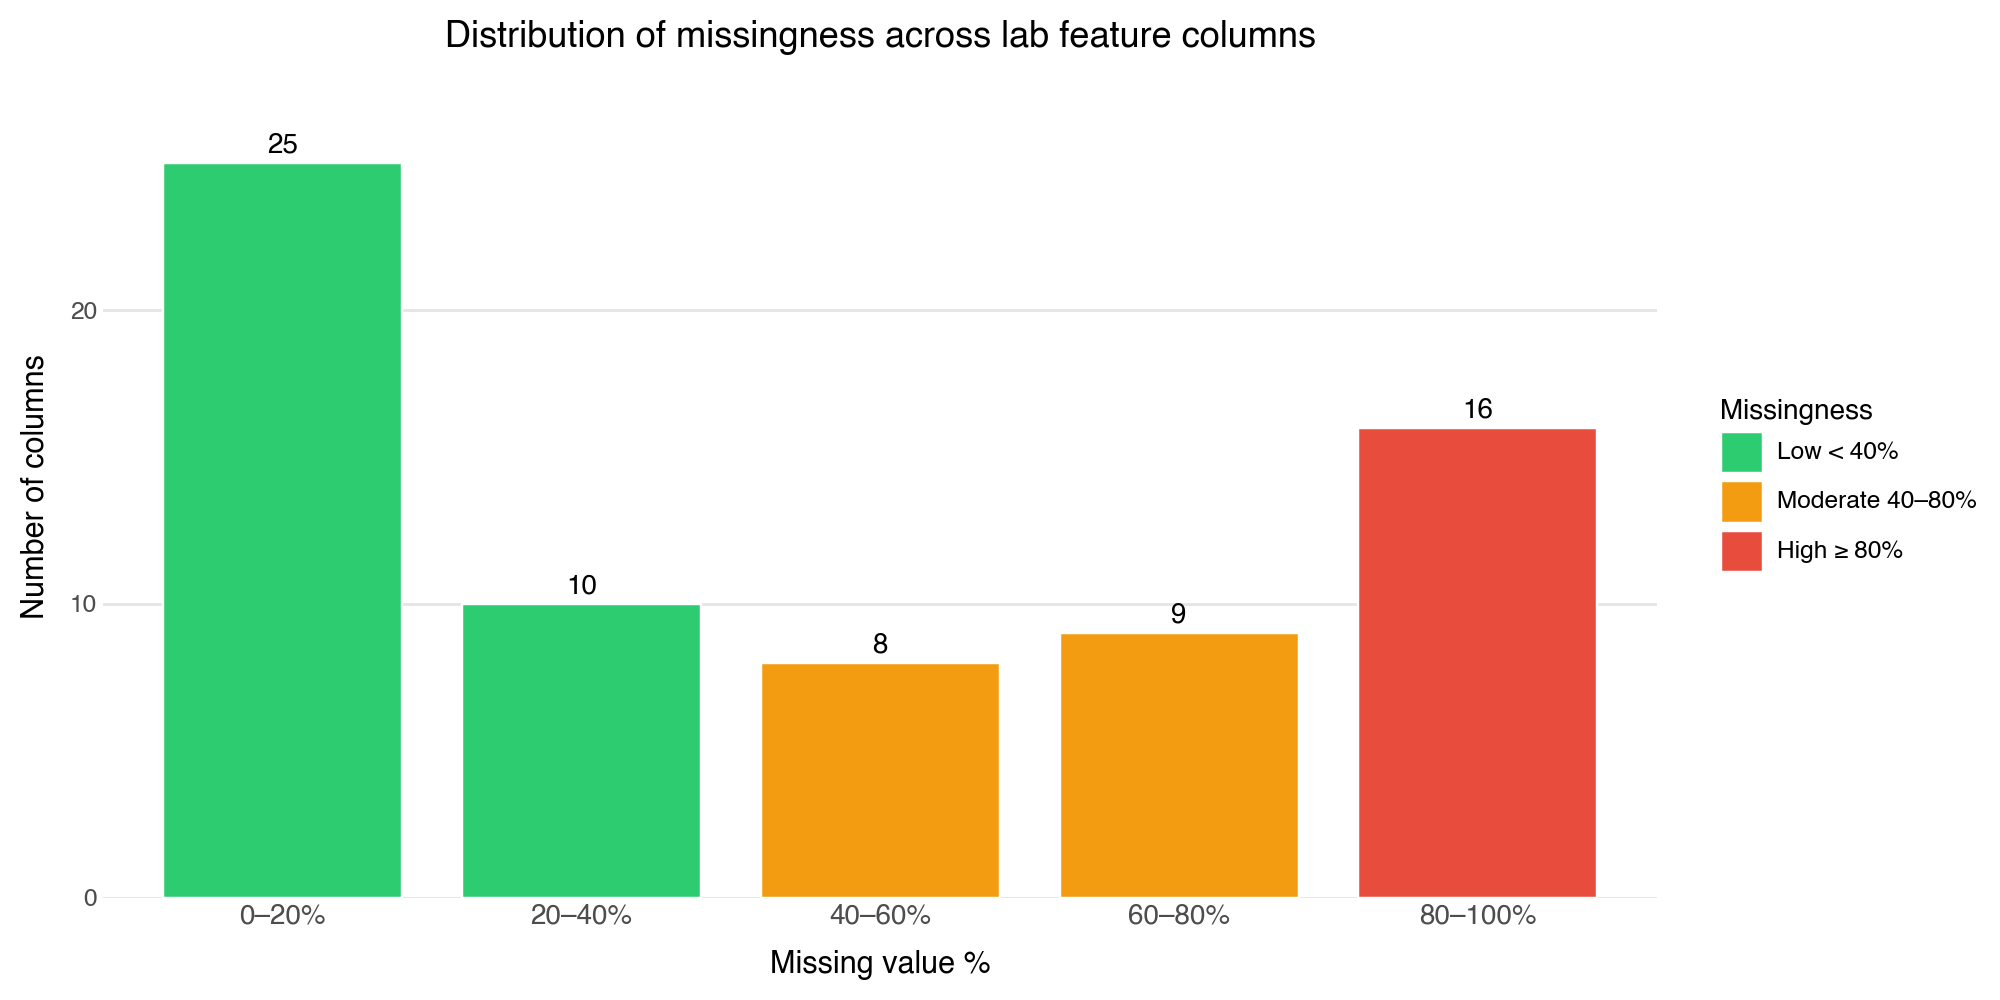

In [78]:
from plotnine import *
from matplotlib import pyplot as plt
import numpy as np


# bin the data manually so we can colour by severity
bins       = np.arange(0, 110, 20)
bin_labels = [f'{int(b)}–{int(b+20)}%' for b in bins[:-1]]
counts, _  = np.histogram(summary['missing_pct'], bins=bins)
bin_starts = bins[:-1]  # [0, 20, 40, 60, 80]

df_missing = pd.DataFrame({
    'bin':   pd.Categorical(bin_labels, categories=bin_labels, ordered=True),
    'count': counts,
    'group': ['High ≥ 80%'       if start >= 80 else
              'Moderate 40–80%'  if start >= 40 else
              'Low < 40%'
              for start in bin_starts]
})

missingness_plot = (
    ggplot(df_missing, aes(x='bin', y='count', fill='group'))
    + geom_col(width=0.8, color='white', size=0.5)
    + geom_text(aes(label='count'), va='bottom', nudge_y=0.15, size=10, fontweight='bold')
    + scale_fill_manual(
        name   = 'Missingness',
        values = {
            'Low < 40%':       '#2ecc71',
            'Moderate 40–80%': '#f39c12',
            'High ≥ 80%':      '#e74c3c',
        },
        breaks = ['Low < 40%', 'Moderate 40–80%', 'High ≥ 80%']
    )
    + scale_y_continuous(expand=(0, 0), limits=(0, max(counts) + 3))
    + labs(
        x     = 'Missing value %',
        y     = 'Number of columns',
        title = 'Distribution of missingness across lab feature columns'
    )
    + theme_minimal()
    + theme(
        axis_text_x      = element_text(size=10),
        panel_grid_major_x = element_blank(),
        panel_grid_minor   = element_blank(),
        plot_title         = element_text(size=13, weight='bold'),
        legend_title       = element_text(size=10),
        figure_size        = (10, 5),
    )
)
missingness_plot.save('missing_histogram.png', dpi=150)

missingness_plot


In [76]:
#Removing all the columns that have 100% missing values

cols_to_drop = df.columns[df.isna().mean() == 1].tolist()
df = df.drop(columns=cols_to_drop)

In [77]:
df

,subject_id,hadm_id,age,gender,race,insurance,admission_type,los_hours,hospital_expire_flag,wbc_first,...,chloride_max,calcium_first,calcium_max,magnesium_first,magnesium_max,phosphate_first,phosphate_max,organisms_cultured,specimen_types,had_resistance
0,10000032,22595853,52,F,WHITE,Medicaid,URGENT,19,0,NaN,...,105.0,7.8,7.8,1.7,1.7,3.6,3.6,NaN,"PERITONEAL FLUID, SWAB, URINE",0
1,10000032,22841357,52,F,WHITE,Medicaid,EW EMER.,24,0,13.0,...,92.0,7.8,7.8,1.9,1.9,3.3,3.3,NaN,"URINE, SWAB",0
2,10000032,25742920,52,F,WHITE,Medicaid,EW EMER.,42,0,NaN,...,95.0,8.6,8.8,2.4,2.4,3.9,3.9,NaN,SWAB,0
3,10000032,29079034,52,F,WHITE,Medicaid,EW EMER.,53,0,NaN,...,102.0,9.3,9.3,2.3,2.3,2.4,2.4,NaN,"SWAB, MRSA SCREEN",0
4,10000084,23052089,72,M,WHITE,Medicare,EW EMER.,109,0,NaN,...,104.0,9.9,9.9,2.0,2.0,3.7,3.7,NaN,BLOOD CULTURE,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
198504,19999828,25744818,46,F,WHITE,Medicaid,EW EMER.,241,0,NaN,...,109.0,9.0,9.3,2.3,2.9,1.1,5.0,"MIXED BACTERIAL FLORA, STREPTOCOCCUS ANGINOSUS...","SWAB, BLOOD CULTURE",0
198505,19999828,29734428,46,F,WHITE,Medicaid,EW EMER.,410,0,13.0,...,117.0,8.6,10.0,1.8,2.9,3.1,5.1,ESCHERICHIA COLI,"URINE, CATHETER TIP-IV, BLOOD CULTURE",1
198506,19999840,21033226,58,M,WHITE,Private,EW EMER.,168,1,NaN,...,117.0,9.3,9.3,2.1,2.2,4.0,4.9,ESCHERICHIA COLI,"SPUTUM, MRSA SCREEN, STOOL, BLOOD CULTURE",0
198507,19999840,26071774,58,M,WHITE,Private,EW EMER.,84,0,5.0,...,106.0,8.8,9.0,1.7,1.9,2.0,2.5,NaN,URINE,0


In [5]:
df

,subject_id,hadm_id,age,gender,race,insurance,admission_type,los_hours,hospital_expire_flag,wbc_first,...,chloride_max,calcium_first,calcium_max,magnesium_first,magnesium_max,phosphate_first,phosphate_max,organisms_cultured,specimen_types,had_resistance
0,10000032,22595853,52,F,WHITE,Medicaid,URGENT,19,0,NaN,...,105.0,7.8,7.8,1.7,1.7,3.6,3.6,NaN,"PERITONEAL FLUID, SWAB, URINE",0
1,10000032,22841357,52,F,WHITE,Medicaid,EW EMER.,24,0,13.0,...,92.0,7.8,7.8,1.9,1.9,3.3,3.3,NaN,"URINE, SWAB",0
2,10000032,25742920,52,F,WHITE,Medicaid,EW EMER.,42,0,NaN,...,95.0,8.6,8.8,2.4,2.4,3.9,3.9,NaN,SWAB,0
3,10000032,29079034,52,F,WHITE,Medicaid,EW EMER.,53,0,NaN,...,102.0,9.3,9.3,2.3,2.3,2.4,2.4,NaN,"SWAB, MRSA SCREEN",0
4,10000084,23052089,72,M,WHITE,Medicare,EW EMER.,109,0,NaN,...,104.0,9.9,9.9,2.0,2.0,3.7,3.7,NaN,BLOOD CULTURE,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
198504,19999828,25744818,46,F,WHITE,Medicaid,EW EMER.,241,0,NaN,...,109.0,9.0,9.3,2.3,2.9,1.1,5.0,"MIXED BACTERIAL FLORA, STREPTOCOCCUS ANGINOSUS...","SWAB, BLOOD CULTURE",0
198505,19999828,29734428,46,F,WHITE,Medicaid,EW EMER.,410,0,13.0,...,117.0,8.6,10.0,1.8,2.9,3.1,5.1,ESCHERICHIA COLI,"URINE, CATHETER TIP-IV, BLOOD CULTURE",1
198506,19999840,21033226,58,M,WHITE,Private,EW EMER.,168,1,NaN,...,117.0,9.3,9.3,2.1,2.2,4.0,4.9,ESCHERICHIA COLI,"SPUTUM, MRSA SCREEN, STOOL, BLOOD CULTURE",0
198507,19999840,26071774,58,M,WHITE,Private,EW EMER.,84,0,5.0,...,106.0,8.8,9.0,1.7,1.9,2.0,2.5,NaN,URINE,0


In [34]:
df.columns

Index(['subject_id', 'hadm_id', 'age', 'gender', 'race', 'insurance',
       'admission_type', 'los_hours', 'hospital_expire_flag', 'wbc_first',
       'wbc_max', 'bands_first', 'bands_max', 'neutrophils_first',
       'neutrophils_max', 'lymphocytes_first', 'lymphocytes_max',
       'monocytes_first', 'monocytes_max', 'crp_first', 'crp_max',
       'ferritin_first', 'ferritin_max', 'lactate_first', 'lactate_max',
       'creatinine_first', 'creatinine_max', 'bilirubin_total_first',
       'bilirubin_total_max', 'alt_first', 'alt_max', 'albumin_first',
       'albumin_max', 'glucose_first', 'glucose_max', 'inr_first', 'inr_max',
       'ptt_first', 'ptt_max', 'platelets_first', 'platelets_max',
       'd_dimer_first', 'd_dimer_max', 'ph_first', 'ph_max', 'po2_first',
       'po2_max', 'pco2_first', 'pco2_max', 'bicarbonate_first',
       'bicarbonate_max', 'hemoglobin_first', 'hemoglobin_max',
       'hematocrit_first', 'hematocrit_max', 'sodium_first', 'sodium_max',
       'potassium_

In [6]:
DROP_COLS  = ['subject_id', 'hadm_id', 'organisms_cultured', 'specimen_types', 'gender', 'race', 'insurance','admission_type']
CAT_COLS   = []
LAB_COLS = [c for c in df.columns
            if c.endswith('_first') or c.endswith('_max')]
TARGET_COL = 'had_resistance'

In [7]:
for col in LAB_COLS:
    df[f'{col}_missing'] = df[col].isna().astype(int)

In [ ]:
df = pd.get_dummies(df, columns=CAT_COLS, drop_first=True)
df = df.drop(columns=DROP_COLS)

In [12]:
df_balanced = pd.concat([
    df[df[TARGET_COL] == 0].sample(20000, random_state=42),
    df[df[TARGET_COL] == 1].sample(20000, random_state=42)
]).reset_index(drop=True)

In [14]:
X = df_balanced.drop(columns=[TARGET_COL])
y = df_balanced[TARGET_COL]

In [15]:
X

,age,los_hours,hospital_expire_flag,wbc_first,wbc_max,bands_first,bands_max,neutrophils_first,neutrophils_max,lymphocytes_first,...,potassium_first_missing,potassium_max_missing,chloride_first_missing,chloride_max_missing,calcium_first_missing,calcium_max_missing,magnesium_first_missing,magnesium_max_missing,phosphate_first_missing,phosphate_max_missing
0,72,138,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0
1,61,79,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0,0,0,1,1,0,0,1,1
2,35,186,0,NaN,NaN,0.0,0.0,79.0,79.0,17.0,...,0,0,0,0,0,0,0,0,0,0
3,50,387,0,1.0,78.0,NaN,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0
4,91,55,1,3.0,3.0,NaN,NaN,92.2,92.2,4.4,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39995,86,508,0,5.0,68.0,NaN,NaN,53.8,62.6,39.1,...,0,0,0,0,0,0,0,0,0,0
39996,74,1503,0,36.0,36.0,2.0,26.0,48.0,94.0,35.0,...,0,0,0,0,0,0,0,0,0,0
39997,86,133,0,86.0,86.0,1.0,1.0,89.0,89.0,6.0,...,0,0,0,0,0,0,0,0,0,0
39998,77,288,0,5.0,5.0,NaN,NaN,77.7,77.7,18.9,...,0,0,0,0,0,0,0,0,0,0


In [16]:
# See what's still non-numeric
print(X.select_dtypes(exclude='number').dtypes)

Series([], dtype: object)


In [42]:
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer, IterativeImputer
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score, f1_score
from sklearn.model_selection import train_test_split

In [44]:
%%script false --no-raise-error

median_imputer = SimpleImputer(strategy='median')
X_median = pd.DataFrame(
    median_imputer.fit_transform(X),
    columns=median_imputer.get_feature_names_out()
)

mice_imputer = IterativeImputer(max_iter=10, random_state=42)
X_mice = pd.DataFrame(
    mice_imputer.fit_transform(X),
    columns=mice_imputer.get_feature_names_out()
)

X_median.to_csv('data/features_imputed_median.csv')
X_mice.to_csv('data/features_imputed_mice.csv')
y.to_csv('data/target.csv')

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import tqdm as notebook_tqdm

# Set globally for all plots
plt.rcParams.update({
    "figure.figsize": (10, 6),   # width, height in inches
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
})
import warnings
warnings.filterwarnings('ignore')

In [45]:
X_median = pd.read_csv('data/features_imputed_median.csv')
X_mice = pd.read_csv('data/features_imputed_mice.csv')

In [26]:
X_median_train, X_test, y_train, y_test = train_test_split(X_median, y, test_size=0.3, train_size=0.7, random_state=42)

In [27]:
models = {
    'decision_tree': DecisionTreeClassifier(),
    'random_forest': RandomForestClassifier(),
    'gradient_boosting':GradientBoostingClassifier()
}

model_perfomance = {}
shap_values = {}

for model_name in models:
    model = models[model_name]
    model.fit(X_median_train, y_train)

    y_pred = model.predict(X_test)

    model_perfomance[model_name] = {'accuracy': accuracy_score(y_test, y_pred),
                                    'f1_score': f1_score(y_test, y_pred)}


print(model_perfomance)

{'decision_tree': {'accuracy': 0.594, 'f1_score': 0.595952894344004}, 'random_forest': {'accuracy': 0.6826666666666666, 'f1_score': 0.6796769851951547}, 'gradient_boosting': {'accuracy': 0.6815833333333333, 'f1_score': 0.6761589965251292}}


In [28]:
X_mice_train, X_test, y_train, y_test = train_test_split(X_mice, y, test_size=0.3, train_size=0.7, random_state=42)

In [29]:
models = {
    'decision_tree': DecisionTreeClassifier(),
    'random_forest': RandomForestClassifier(),
    'gradient_boosting':GradientBoostingClassifier()
}

model_perfomance = {}
shap_values = {}

for model_name in models:
    model = models[model_name]
    model.fit(X_mice_train, y_train)

    y_pred = model.predict(X_test)

    model_perfomance[model_name] = {'accuracy': accuracy_score(y_test, y_pred),
                                    'f1_score': f1_score(y_test, y_pred)}


print(model_perfomance)

{'decision_tree': {'accuracy': 0.58425, 'f1_score': 0.5855279554706322}, 'random_forest': {'accuracy': 0.68, 'f1_score': 0.6764408493427705}, 'gradient_boosting': {'accuracy': 0.6826666666666666, 'f1_score': 0.6748078565328779}}


In [39]:
model = DecisionTreeClassifier(max_depth=4, random_state=42, max_leaf_nodes=32)

model.fit(X_mice_train, y_train)

y_pred = model.predict_proba(X_test)

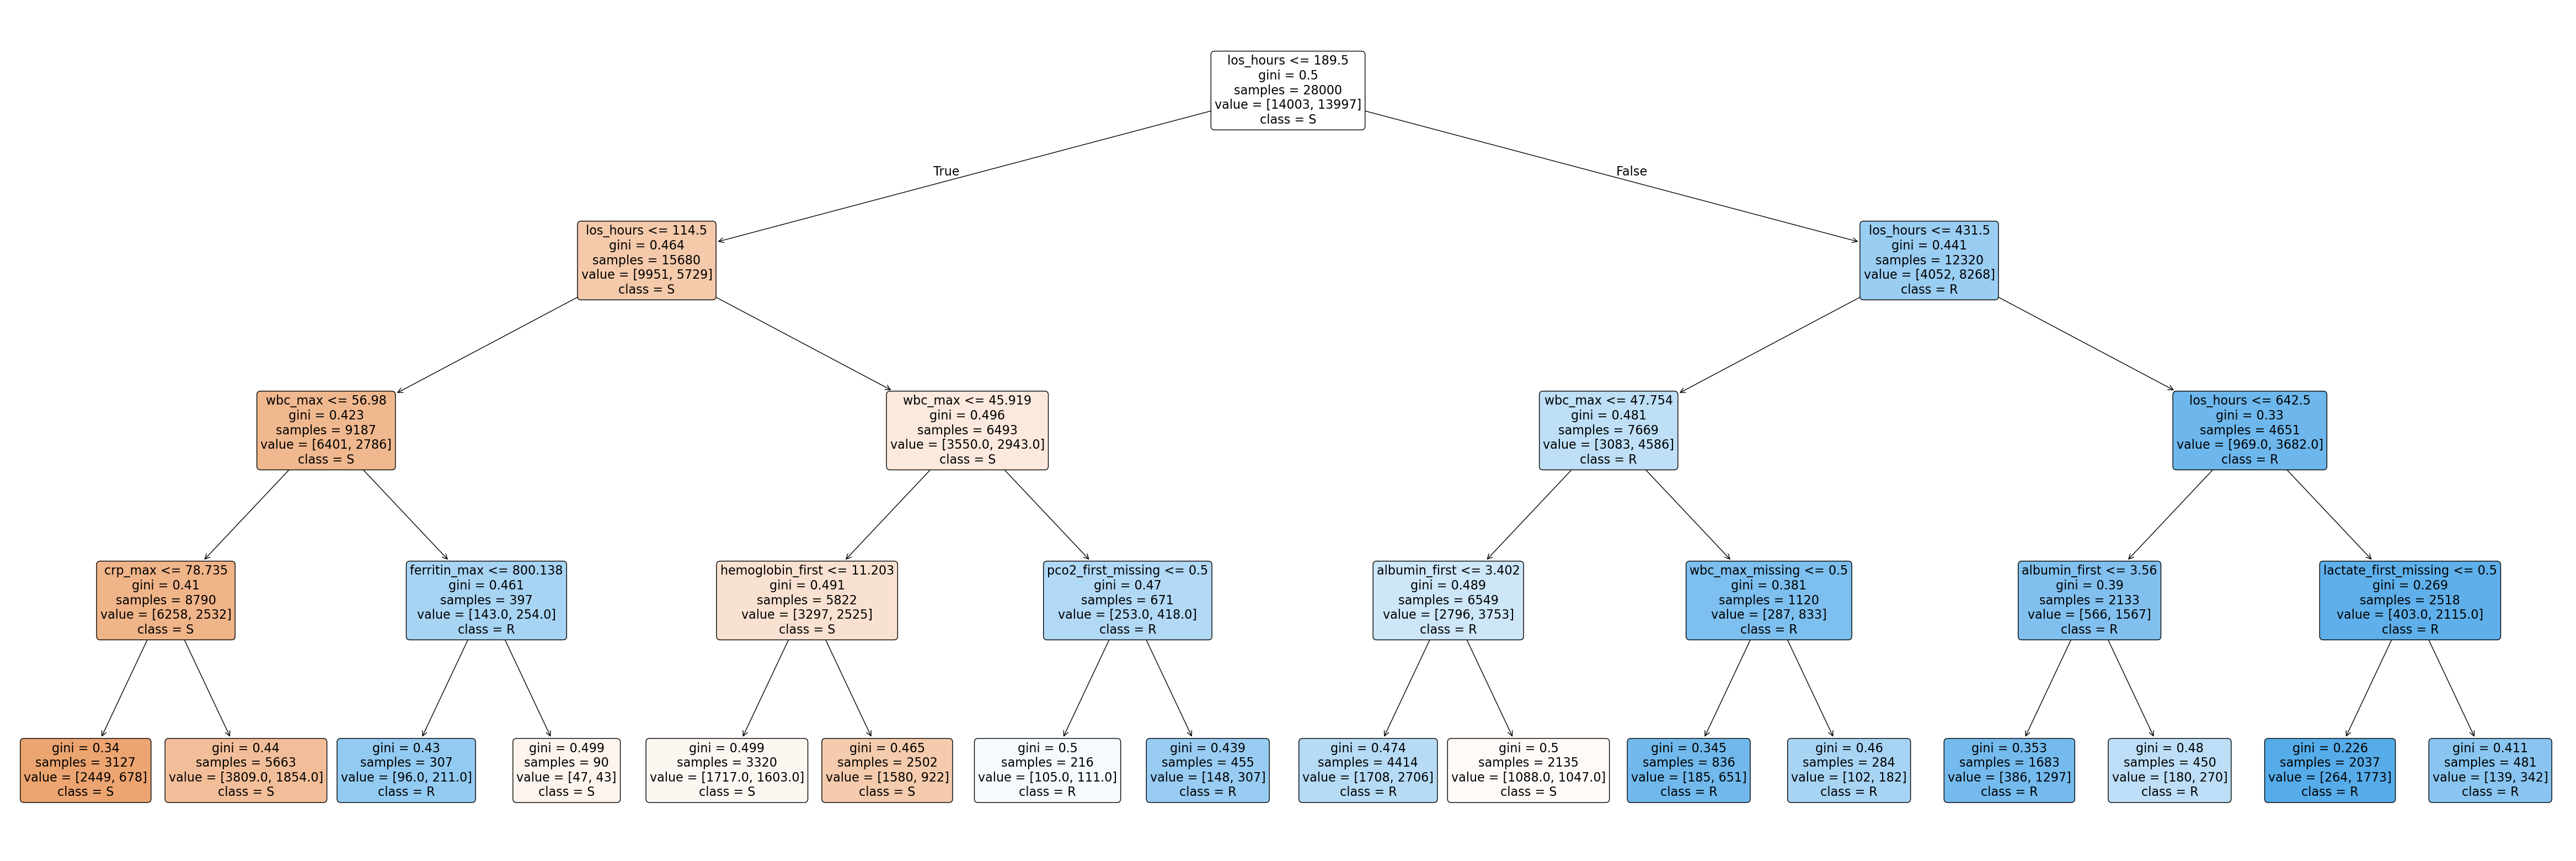

In [ ]:
from sklearn.tree import plot_tree

fig, ax = plt.subplots(figsize=(60, 20))
plot_tree(
    model,                            # your fitted DecisionTreeClassifier
    feature_names=X.columns.tolist(),
    class_names=['S', 'R'],
    filled=True,                    # colour nodes by class
    rounded=True,
    fontsize=16,
    ax=ax
)
plt.savefig('decision_tree.png', dpi=150, bbox_inches='tight')
plt.show()

In [23]:
#explainer = shap.TreeExplainer(model)

#shap_values = explainer(X_test)

In [65]:
df_balanced

,age,los_hours,hospital_expire_flag,wbc_first,wbc_max,bands_first,bands_max,neutrophils_first,neutrophils_max,lymphocytes_first,...,potassium_first_missing,potassium_max_missing,chloride_first_missing,chloride_max_missing,calcium_first_missing,calcium_max_missing,magnesium_first_missing,magnesium_max_missing,phosphate_first_missing,phosphate_max_missing
0,72,138,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0
1,61,79,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0,0,0,1,1,0,0,1,1
2,35,186,0,NaN,NaN,0.0,0.0,79.0,79.0,17.0,...,0,0,0,0,0,0,0,0,0,0
3,50,387,0,1.0,78.0,NaN,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0
4,91,55,1,3.0,3.0,NaN,NaN,92.2,92.2,4.4,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,40,1574,0,1.0,1.0,0.0,10.0,49.0,96.0,22.0,...,0,0,0,0,0,0,0,0,0,0
19996,53,408,0,1.0,1.0,NaN,NaN,88.9,88.9,1.8,...,0,0,0,0,0,0,0,0,0,0
19997,49,77,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0
19998,56,154,0,270.0,270.0,33.0,33.0,22.0,22.0,25.0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
import shap
from ciu import CIU